# Page aging / scanning degradation

Takes one image and applies the degradations a printed figure picks up on its way
into a scanned archive: ink spreading and fading, paper yellowing and texture,
folds and stains, then the scanner or camera's own artifacts.

## What this is based on

The effects and the order they are applied in follow the document-degradation
literature rather than being invented here:

* **[Augraphy](https://arxiv.org/abs/2208.14558)** (ICDAR 2023) is the engine.
  Its central idea is that a document's damage accumulates in three stages, and
  a pipeline should be built the same way:
  **ink phase** (what happens to the ink before/while printing -- bleed, fading,
  low-ink streaks), **paper phase** (the substrate it is printed on -- colour,
  texture, watermarks, stains), and **post phase** (what happens to the printed
  page afterwards -- folding, photocopying, faxing, scanning, photographing).
* **[PreP-OCR](https://arxiv.org/abs/2505.20429)** (2025) generates its training
  degradations by applying operations *in a random order* at **four progressive
  severity levels** -- noise injection, resolution reduction, blur, black/white
  patches, scratch/fold lines, background texture, stains, morphological
  dilation/erosion. The random ordering matters: the same set of operations in
  different sequences produces substantially different results. The severity
  ladder below follows that idea.
* **[scan-simulator](https://github.com/s1mb1o/scan-simulator)** groups
  physically-motivated transforms into paper/aging, physical damage, scanner
  artifacts and camera artifacts, and ships presets like *scan-clean*,
  *scan-heavy*, *photocopy* and *archive*. The preset names here follow it.

Two things worth knowing about what this does **not** do. It is a forward
degradation model only -- there is no restoration here. And every effect is a
classical image operation; recent work also does this with diffusion models
that hallucinate damage, which produces more varied results but is not
reproducible from a seed.


In [1]:
# ============================ CONFIG ============================
# The image to age.  Any path; defaults to the first released VQA figure.
input_image = '~/Dropbox/WASP2026/VQA/imgs/vqa_000001.jpeg'

out_dir = './aged_output/'

# Which preset to apply.  See PRESETS below; 'archive' is a good default.
#   scan-clean | scan-heavy | photocopy | archive | photo-indoor | fax
preset = 'archive'

# Reproducibility.  None -> different every run.
seed = 7

# Work at reduced resolution.  The figures are ~1900x2500; several effects are
# O(pixels) and the whole pipeline runs ~4x faster at half size.  None = full.
work_max_width = 1400

# For the effect gallery: downscale further so the grid renders quickly
gallery_max_width = 700

# ---- effects held back by default -------------------------------------------
# These are realistic for a scanned page but unhelpful here: Scribbles and
# WaterMark add marks that have nothing to do with the figure, BookBinding bends
# the page so far that the plot stops being readable as a plot, and Letterpress
# restyles the ink in a way that fights the colormap.  They stay in the
# catalogue and in the presets; this flag decides whether they are ever used.
OPTIONAL_EFFECTS = ['Scribbles', 'BookBinding', 'WaterMark', 'Letterpress']
use_optional_effects = False      # True -> allow them everywhere

# ---- annotation boxes ------------------------------------------------------
# The stored bounding boxes (plot square, title, x/y labels, colorbar) live in
# the figure's qa json.  None -> look for <stem>_qa.json in the directory below,
# matching the input image's name.
annotations_json = None
annotations_dir = '~/Dropbox/WASP2026/VQA/qa_jsons/'

draw_annotations = True     # also write/display box-annotated copies
annotation_thickness = 4
annotation_labels = True    # write the box name beside each one


In [2]:
import os, glob, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt

import augraphy
from augraphy import (AugraphyPipeline,
                      # ink phase
                      InkBleed, BleedThrough, Letterpress, LowInkRandomLines,
                      LowInkPeriodicLines, InkMottling, LinesDegradation,
                      # paper phase
                      ColorPaper, NoiseTexturize, BrightnessTexturize, WaterMark,
                      Gamma, LightingGradient,
                      # post phase
                      Folding, Stains, BadPhotoCopy, DirtyRollers, DirtyDrum,
                      SubtleNoise, Jpeg, ShadowCast, PageBorder, BookBinding,
                      Geometric, Moire, Faxify, Dithering, NoisyLines,
                      ReflectedLight, LowLightNoise, ColorShift, Squish,
                      SectionShift, Scribbles, Markup)

print('augraphy', augraphy.__version__, '| opencv', cv2.__version__)

input_image = os.path.expanduser(input_image)
out_dir = os.path.expanduser(out_dir)
os.makedirs(out_dir, exist_ok=True)


def load_image(path, max_width=None):
    """BGR uint8, as augraphy expects.  Optionally downscaled for speed."""
    img = cv2.imread(os.path.expanduser(path))
    if img is None:
        raise FileNotFoundError(path)
    if max_width and img.shape[1] > max_width:
        s = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1]*s), int(img.shape[0]*s)),
                         interpolation=cv2.INTER_AREA)
    return img


def show(images, titles=None, ncols=3, width=5, suptitle=None):
    """Grid of BGR images, converted for display."""
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    h, w = images[0].shape[:2]
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(width*ncols, width*nrows*h/w))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis('off')
    for ax, im, t in zip(axes, images, titles or ['']*n):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=11)
    if suptitle:
        fig.suptitle(suptitle, fontsize=15)
    fig.tight_layout()
    return fig


augraphy 8.2.6 | opencv 5.0.0


In [3]:
# ==================== THE EFFECT CATALOGUE ====================
# Grouped the way scan-simulator groups them, but each entry is an augraphy
# augmentation.  Every one of these was checked to run and to actually change
# the image; `DepthSimulatedBlur` is deliberately absent (~13 s per call).
#
# Each value is a zero-argument factory, so a fresh instance is built per use --
# augmentations sample their parameters at construction, and reusing one object
# would repeat the same random draw.

EFFECTS = {
    # ---- ink: what the printed marks themselves suffer ----
    'InkBleed':            ('ink',   lambda: InkBleed(p=1)),
    'BleedThrough':        ('ink',   lambda: BleedThrough(p=1)),
    'Letterpress':         ('ink',   lambda: Letterpress(p=1)),
    'LowInkRandomLines':   ('ink',   lambda: LowInkRandomLines(p=1)),
    'LowInkPeriodicLines': ('ink',   lambda: LowInkPeriodicLines(p=1)),
    'InkMottling':         ('ink',   lambda: InkMottling(p=1)),
    'LinesDegradation':    ('ink',   lambda: LinesDegradation(p=1)),

    # ---- paper: the substrate, its colour, texture and marks ----
    'ColorPaper':          ('paper', lambda: ColorPaper(p=1)),
    'NoiseTexturize':      ('paper', lambda: NoiseTexturize(p=1)),
    'BrightnessTexturize': ('paper', lambda: BrightnessTexturize(p=1)),
    'WaterMark':           ('paper', lambda: WaterMark(p=1)),
    'Gamma':               ('paper', lambda: Gamma(p=1)),
    'LightingGradient':    ('paper', lambda: LightingGradient(p=1)),

    # ---- physical damage to the printed page ----
    'Folding':             ('post',  lambda: Folding(p=1)),
    'Stains':              ('post',  lambda: Stains(p=1)),
    'PageBorder':          ('post',  lambda: PageBorder(p=1)),
    'BookBinding':         ('post',  lambda: BookBinding(p=1)),
    'Scribbles':           ('post',  lambda: Scribbles(p=1)),
    'Markup':              ('post',  lambda: Markup(p=1)),

    # ---- scanner / copier artifacts ----
    # NOTE on these two: augraphy's defaults assume a text page that is mostly
    # white, where heavy speckle reads as toner noise.  On a dense figure they
    # swamp the image, so both are dialled back here -- BadPhotoCopy to a low,
    # sparse, single-sided noise, and DirtyRollers to narrow scanlines.
    'BadPhotoCopy':        ('post',  lambda: BadPhotoCopy(
                                         noise_type=2, noise_side='bottom',
                                         noise_iteration=(1, 1), noise_size=(1, 2),
                                         noise_value=(160, 220),
                                         noise_sparsity=(0.05, 0.2),
                                         noise_concentration=(0.02, 0.08),
                                         edge_effect=0, wave_pattern=0, p=1)),
    'DirtyRollers':        ('post',  lambda: DirtyRollers(
                                         line_width_range=(2, 5), p=1)),
    'DirtyDrum':           ('post',  lambda: DirtyDrum(p=1)),
    'Moire':               ('post',  lambda: Moire(p=1)),
    'Faxify':              ('post',  lambda: Faxify(p=1)),
    'Dithering':           ('post',  lambda: Dithering(p=1)),
    'NoisyLines':          ('post',  lambda: NoisyLines(p=1)),
    'SectionShift':        ('post',  lambda: SectionShift(p=1)),

    # ---- camera / sensor artifacts ----
    'ShadowCast':          ('post',  lambda: ShadowCast(p=1)),
    'ReflectedLight':      ('post',  lambda: ReflectedLight(p=1)),
    'LowLightNoise':       ('post',  lambda: LowLightNoise(p=1)),
    'SubtleNoise':         ('post',  lambda: SubtleNoise(p=1)),
    'ColorShift':          ('post',  lambda: ColorShift(p=1)),
    'Jpeg':                ('post',  lambda: Jpeg(p=1)),

    # ---- geometry ----
    'Geometric':           ('post',  lambda: Geometric(rotate_range=(-3, 3), p=1)),
    'Squish':              ('post',  lambda: Squish(p=1)),
}


# ==================== PRESETS ====================
# name -> {phase: [(effect name, probability), ...]}.  Probabilities give the
# PreP-OCR-style severity ladder: the same effects, applied more often and in
# more combinations as severity rises.

PRESETS = {
    # a well-maintained office scanner: barely touched
    'scan-clean': {
        'ink':   [('InkBleed', 0.3)],
        'paper': [('ColorPaper', 0.3), ('BrightnessTexturize', 0.3)],
        'post':  [('Geometric', 0.5), ('SubtleNoise', 0.5), ('Jpeg', 0.7)],
    },
    # an old or cheap scanner pulling through aged paper
    'scan-heavy': {
        'ink':   [('InkBleed', 0.8), ('Letterpress', 0.4), ('LowInkRandomLines', 0.4)],
        'paper': [('ColorPaper', 0.8), ('NoiseTexturize', 0.7),
                  ('BrightnessTexturize', 0.6), ('LightingGradient', 0.5)],
        'post':  [('Geometric', 0.7), ('DirtyRollers', 0.35), ('DirtyDrum', 0.4),
                  ('Folding', 0.4), ('ShadowCast', 0.4), ('SubtleNoise', 0.8),
                  ('Jpeg', 0.8)],
    },
    # several generations through a photocopier
    'photocopy': {
        'ink':   [('InkBleed', 0.7), ('Letterpress', 0.6),
                  ('LowInkPeriodicLines', 0.5), ('LinesDegradation', 0.4)],
        'paper': [('ColorPaper', 0.5), ('BrightnessTexturize', 0.5)],
        'post':  [('BadPhotoCopy', 0.6), ('DirtyDrum', 0.5), ('DirtyRollers', 0.4),
                  ('Geometric', 0.6), ('SubtleNoise', 0.7), ('Jpeg', 0.8)],
    },
    # decades in a box: yellowed, foxed, folded, then scanned
    'archive': {
        'ink':   [('InkBleed', 0.8), ('BleedThrough', 0.6), ('InkMottling', 0.5),
                  ('Letterpress', 0.3)],
        'paper': [('ColorPaper', 0.9), ('NoiseTexturize', 0.8),
                  ('BrightnessTexturize', 0.7), ('LightingGradient', 0.4)],
        'post':  [('Stains', 0.8), ('Folding', 0.6), ('PageBorder', 0.5),
                  ('ShadowCast', 0.4), ('Geometric', 0.6), ('SubtleNoise', 0.7),
                  ('Jpeg', 0.7)],
    },
    # a phone photo of a page, indoors
    'photo-indoor': {
        'ink':   [('InkBleed', 0.4)],
        'paper': [('ColorPaper', 0.5), ('BrightnessTexturize', 0.5)],
        'post':  [('ShadowCast', 0.8),
                  ('ReflectedLight', 0.6), ('LowLightNoise', 0.6),
                  ('ColorShift', 0.4), ('Geometric', 0.8), ('Jpeg', 0.9)],
    },
    # through a fax machine: 1-bit, streaked
    'fax': {
        'ink':   [('InkBleed', 0.6), ('LowInkPeriodicLines', 0.6)],
        'paper': [('BrightnessTexturize', 0.4)],
        'post':  [('Faxify', 1.0), ('NoisyLines', 0.5), ('DirtyRollers', 0.5),
                  ('Geometric', 0.5), ('Jpeg', 0.6)],
    },
}


def effect_enabled(name):
    """False for the held-back effects unless use_optional_effects is set."""
    return use_optional_effects or name not in OPTIONAL_EFFECTS


def build_pipeline(preset_name, seed=None, keypoints=None):
    """
    An AugraphyPipeline for one preset, with fresh augmentation instances.

    `keypoints` is passed straight through to augraphy: hand it the corners of
    the annotation boxes and they come back moved by the same geometry that
    moved the pixels.  Note the pipeline then returns
    [image, mask, keypoints, bounding_boxes] rather than a bare image.
    """
    spec = PRESETS[preset_name]
    phases = {}
    for phase in ('ink', 'paper', 'post'):
        objs = []
        for name, prob in spec.get(phase, []):
            if prob <= 0 or not effect_enabled(name):
                continue
            phase_of, factory = EFFECTS[name]
            aug = factory()
            aug.p = prob          # the preset sets how often it fires
            objs.append(aug)
        phases[phase] = objs
    return AugraphyPipeline(ink_phase=phases['ink'],
                            paper_phase=phases['paper'],
                            post_phase=phases['post'],
                            keypoints=keypoints,
                            random_seed=seed)


_off = [n for n in EFFECTS if not effect_enabled(n)]
print('presets : ', ', '.join(PRESETS))
print('effects : %d in the catalogue, %d enabled' % (len(EFFECTS), len(EFFECTS) - len(_off)))
if _off:
    print('held back: %s   (set use_optional_effects = True to include them)'
          % ', '.join(_off))


presets :  scan-clean, scan-heavy, photocopy, archive, photo-indoor, fax
effects : 35 in the catalogue, 31 enabled
held back: Letterpress, WaterMark, BookBinding, Scribbles   (set use_optional_effects = True to include them)


input : vqa_000001.jpeg  1400x1057
preset: archive       0.6s
wrote : ./aged_output/vqa_000001_archive.png


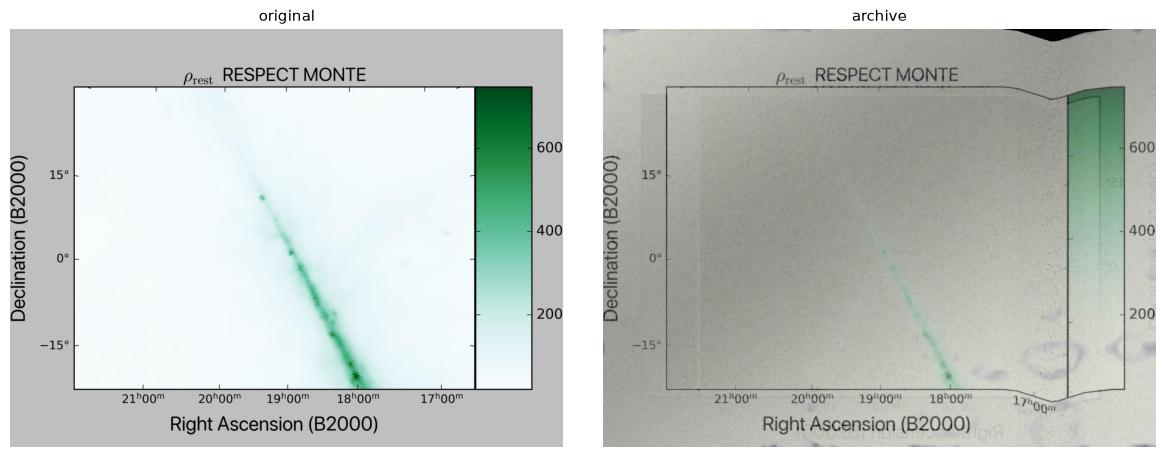

In [4]:
# ==================== APPLY ONE PRESET ====================
img = load_image(input_image, max_width=work_max_width)
print('input : %s  %dx%d' % (os.path.basename(input_image), img.shape[1], img.shape[0]))

t0 = time.time()
pipeline = build_pipeline(preset, seed=seed)
aged = pipeline(img.copy())
print('preset: %-12s  %.1fs' % (preset, time.time() - t0))

stem = os.path.splitext(os.path.basename(input_image))[0]
out_path = os.path.join(out_dir, '%s_%s.png' % (stem, preset))
cv2.imwrite(out_path, aged)
print('wrote :', out_path)

fig = show([img, aged], ['original', preset], ncols=2, width=6)


In [5]:
# ==================== ANNOTATION BOXES ====================
# The stored bounding boxes -- plot square, title, x/y labels, colorbar -- drawn
# on the aged page, moved by the same transforms that moved the pixels.
#
# add_annotations_v1 (skyfigs/utils/figure_gen_utils/misc.py) draws them on a
# CLEAN figure and assumes the image still matches the coordinates.  Once the
# page is rotated and padded that is false, so annotate_transform.py reworks it:
# the four corners of every box are handed to augraphy as keypoints and come
# back rotated with the page.  Corners rather than `bounding_boxes` because
# augraphy translates boxes but does not rotate them -- see the module docstring
# for the measurement.
import sys
if '.' not in sys.path:
    sys.path.insert(0, '.')
import annotate_transform
from importlib import reload
reload(annotate_transform)
from annotate_transform import (collect_quads, draw_quads, flatten_quads,
                                unpack_result, quad_to_aabb, BOX_KEYS)

def find_annotations(image_path):
    """The qa json holding this figure's boxes, or None."""
    if annotations_json:
        return os.path.expanduser(annotations_json)
    stem = os.path.splitext(os.path.basename(image_path))[0]
    cand = os.path.join(os.path.expanduser(annotations_dir), stem + '_qa.json')
    return cand if os.path.exists(cand) else None


def load_annotations(image_path):
    """The per-figure dict the boxes live in (double-encoded json)."""
    path = find_annotations(image_path)
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    return json.loads(d) if isinstance(d, str) else d


def aged_with_boxes(image, quads, preset_name, seed=None):
    """Run one preset over `image`, carrying `quads` with it."""
    labels, keypoints = flatten_quads(quads)
    result = build_pipeline(preset_name, seed=seed, keypoints=keypoints)(image.copy())
    return unpack_result(result, labels, keypoints['annotation_corners'])


def annotate(image, quads):
    return draw_quads(image, quads, linethick=annotation_thickness,
                      label_text=annotation_labels)


datas_plot = load_annotations(input_image) if draw_annotations else None
if datas_plot is None:
    print('no annotation json for %s -- annotated outputs will be skipped'
          % os.path.basename(input_image))
    print('(looked for: %s)' % find_annotations(input_image))
    quads = []
else:
    # scale the boxes to whatever resolution we are working at
    full = load_image(input_image)
    quads_full = collect_quads(datas_plot, full.shape[0])
    s = img.shape[1] / full.shape[1]
    quads = [(lab, [[int(round(x*s)), int(round(y*s))] for x, y in q])
             for lab, q in quads_full]
    print('%d annotation boxes: %s' % (len(quads), ', '.join(l for l, _ in quads)))
    print('scaled by %.3f to the working image (%dx%d)' % (s, img.shape[1], img.shape[0]))


5 annotation boxes: square, title, xlabel, ylabel, color bar
scaled by 0.569 to the working image (1400x1057)


wrote : ./aged_output/vqa_000001_archive_annotated.png
box         AABB before                AABB after
square      [162, 146, 1175, 912]      [162, 146, 1175, 934]
title       [437, 96, 900, 143]        [437, 96, 900, 143]
xlabel      [404, 980, 934, 1026]      [404, 980, 934, 1026]
ylabel      [1, 316, 47, 742]          [1, 316, 47, 742]
color bar   [1178, 146, 1320, 912]     [1178, 146, 1320, 933]


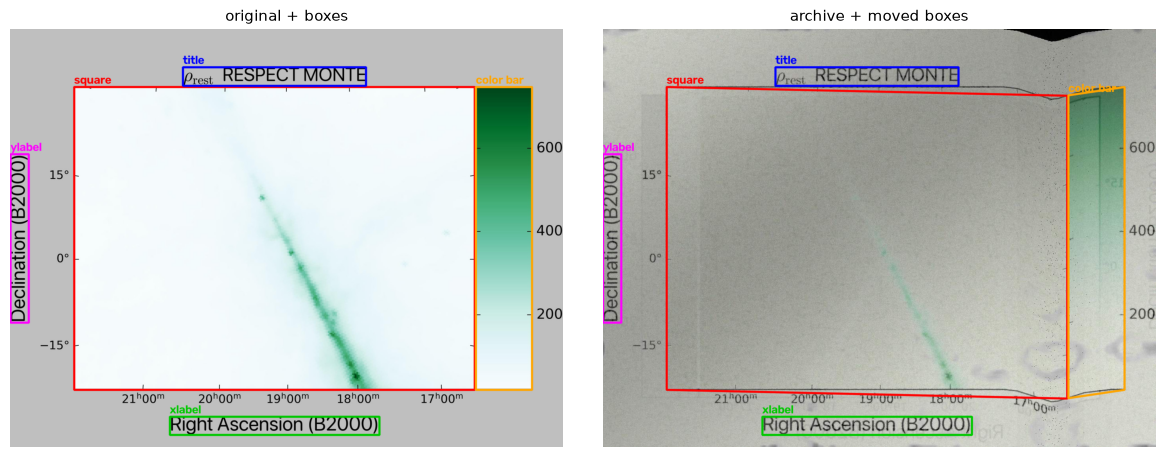

In [6]:
# ---------- one preset, annotated ----------
if quads:
    aged_a, quads_moved = aged_with_boxes(img, quads, preset, seed=seed)
    out_a = os.path.join(out_dir, '%s_%s_annotated.png' % (stem, preset))
    cv2.imwrite(out_a, annotate(aged_a, quads_moved))
    print('wrote :', out_a)
    print('%-11s %-26s %s' % ('box', 'AABB before', 'AABB after'))
    for (l, q0), (_, q1) in zip(quads, quads_moved):
        print('%-11s %-26s %s' % (l, quad_to_aabb(q0), quad_to_aabb(q1)))
    fig = show([annotate(img, quads), annotate(aged_a, quads_moved)],
               ['original + boxes', '%s + moved boxes' % preset],
               ncols=2, width=6)


wrote ./aged_output/vqa_000001_all_presets.png


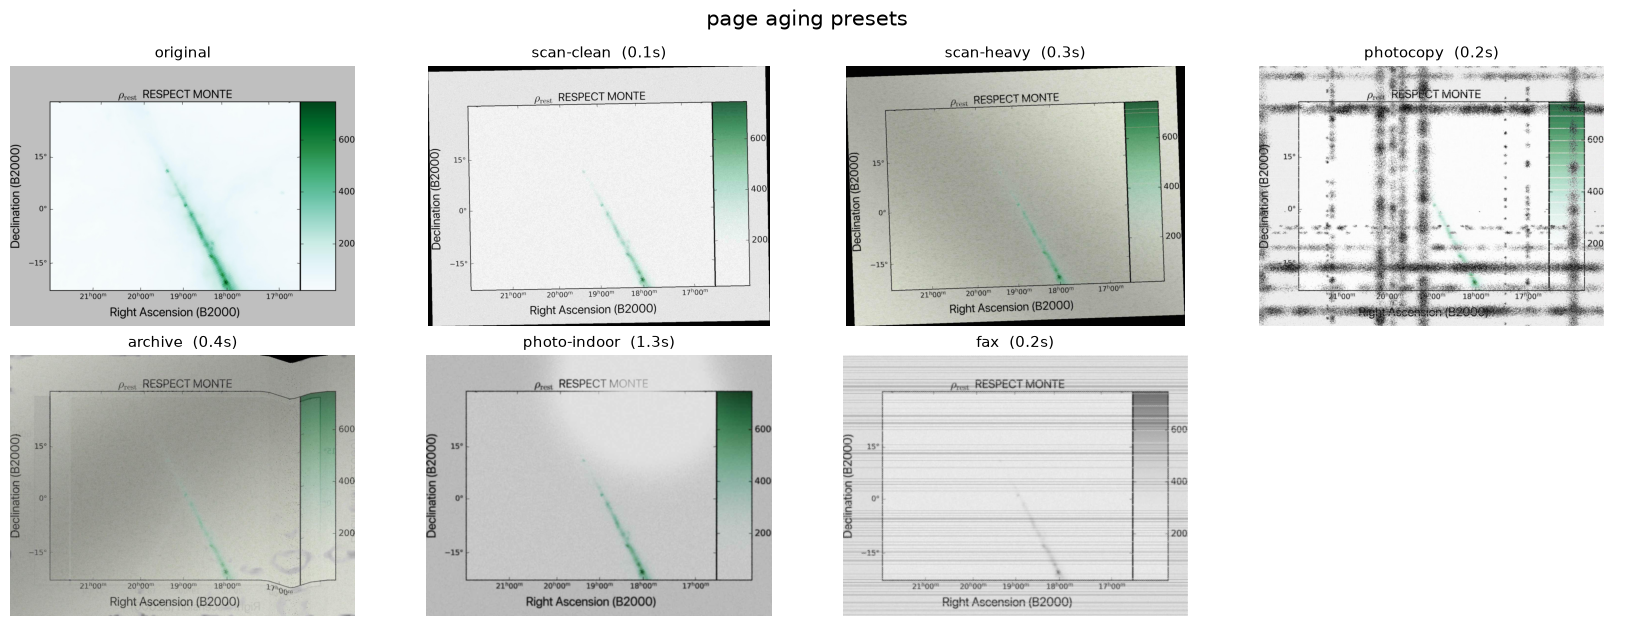

In [7]:
# ==================== ALL PRESETS, SIDE BY SIDE ====================
imgs, titles = [img], ['original']
for name in PRESETS:
    t0 = time.time()
    imgs.append(build_pipeline(name, seed=seed)(img.copy()))
    titles.append('%s  (%.1fs)' % (name, time.time() - t0))

fig = show(imgs, titles, ncols=4, width=4.2, suptitle='page aging presets')
fig.savefig(os.path.join(out_dir, '%s_all_presets.png' % stem),
            dpi=110, bbox_inches='tight')
print('wrote', os.path.join(out_dir, '%s_all_presets.png' % stem))


wrote ./aged_output/vqa_000001_all_presets_annotated.png


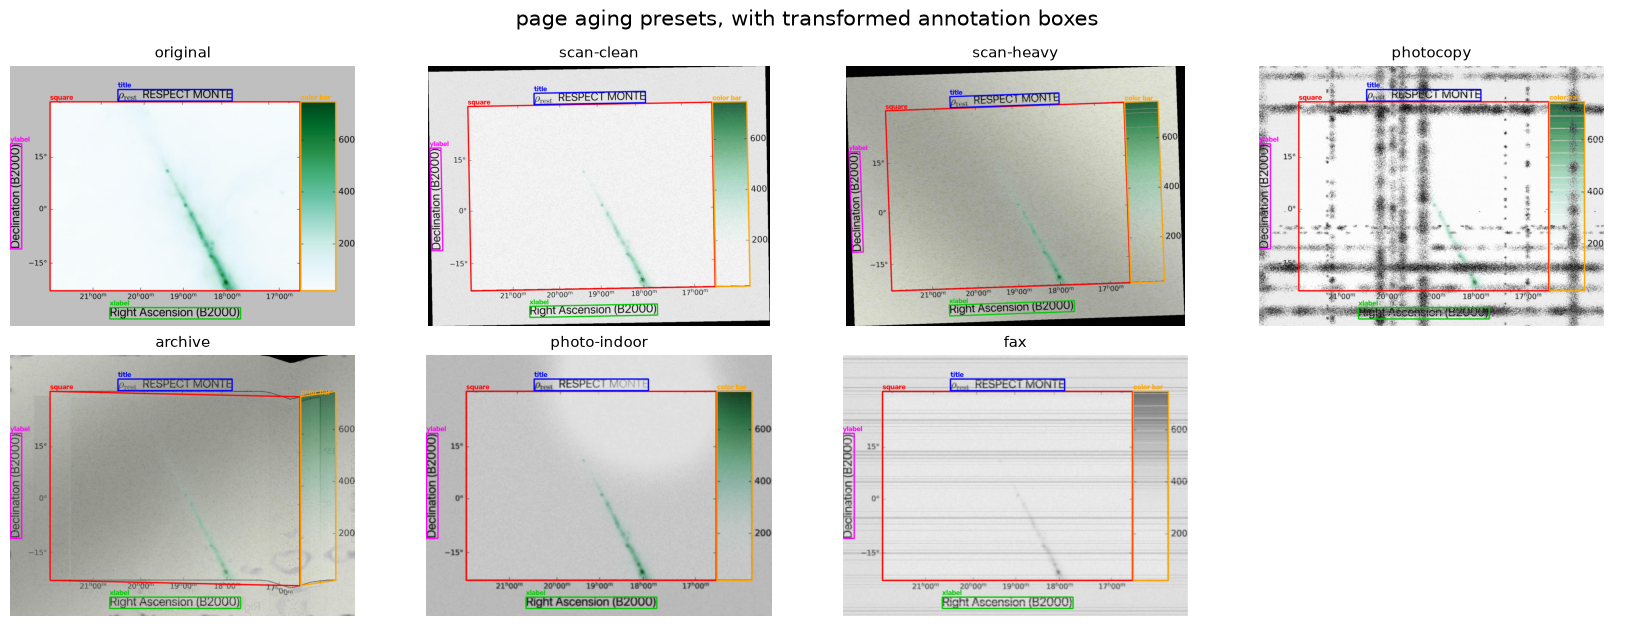

In [8]:
# ---------- all presets, annotated ----------
if quads:
    imgs_a, titles_a = [annotate(img, quads)], ['original']
    for name in PRESETS:
        a, qm = aged_with_boxes(img, quads, name, seed=seed)
        imgs_a.append(annotate(a, qm))
        titles_a.append(name)
    fig = show(imgs_a, titles_a, ncols=4, width=4.2,
               suptitle='page aging presets, with transformed annotation boxes')
    out_a = os.path.join(out_dir, '%s_all_presets_annotated.png' % stem)
    fig.savefig(out_a, dpi=110, bbox_inches='tight')
    print('wrote', out_a)


wrote ./aged_output/vqa_000001_effect_gallery.png


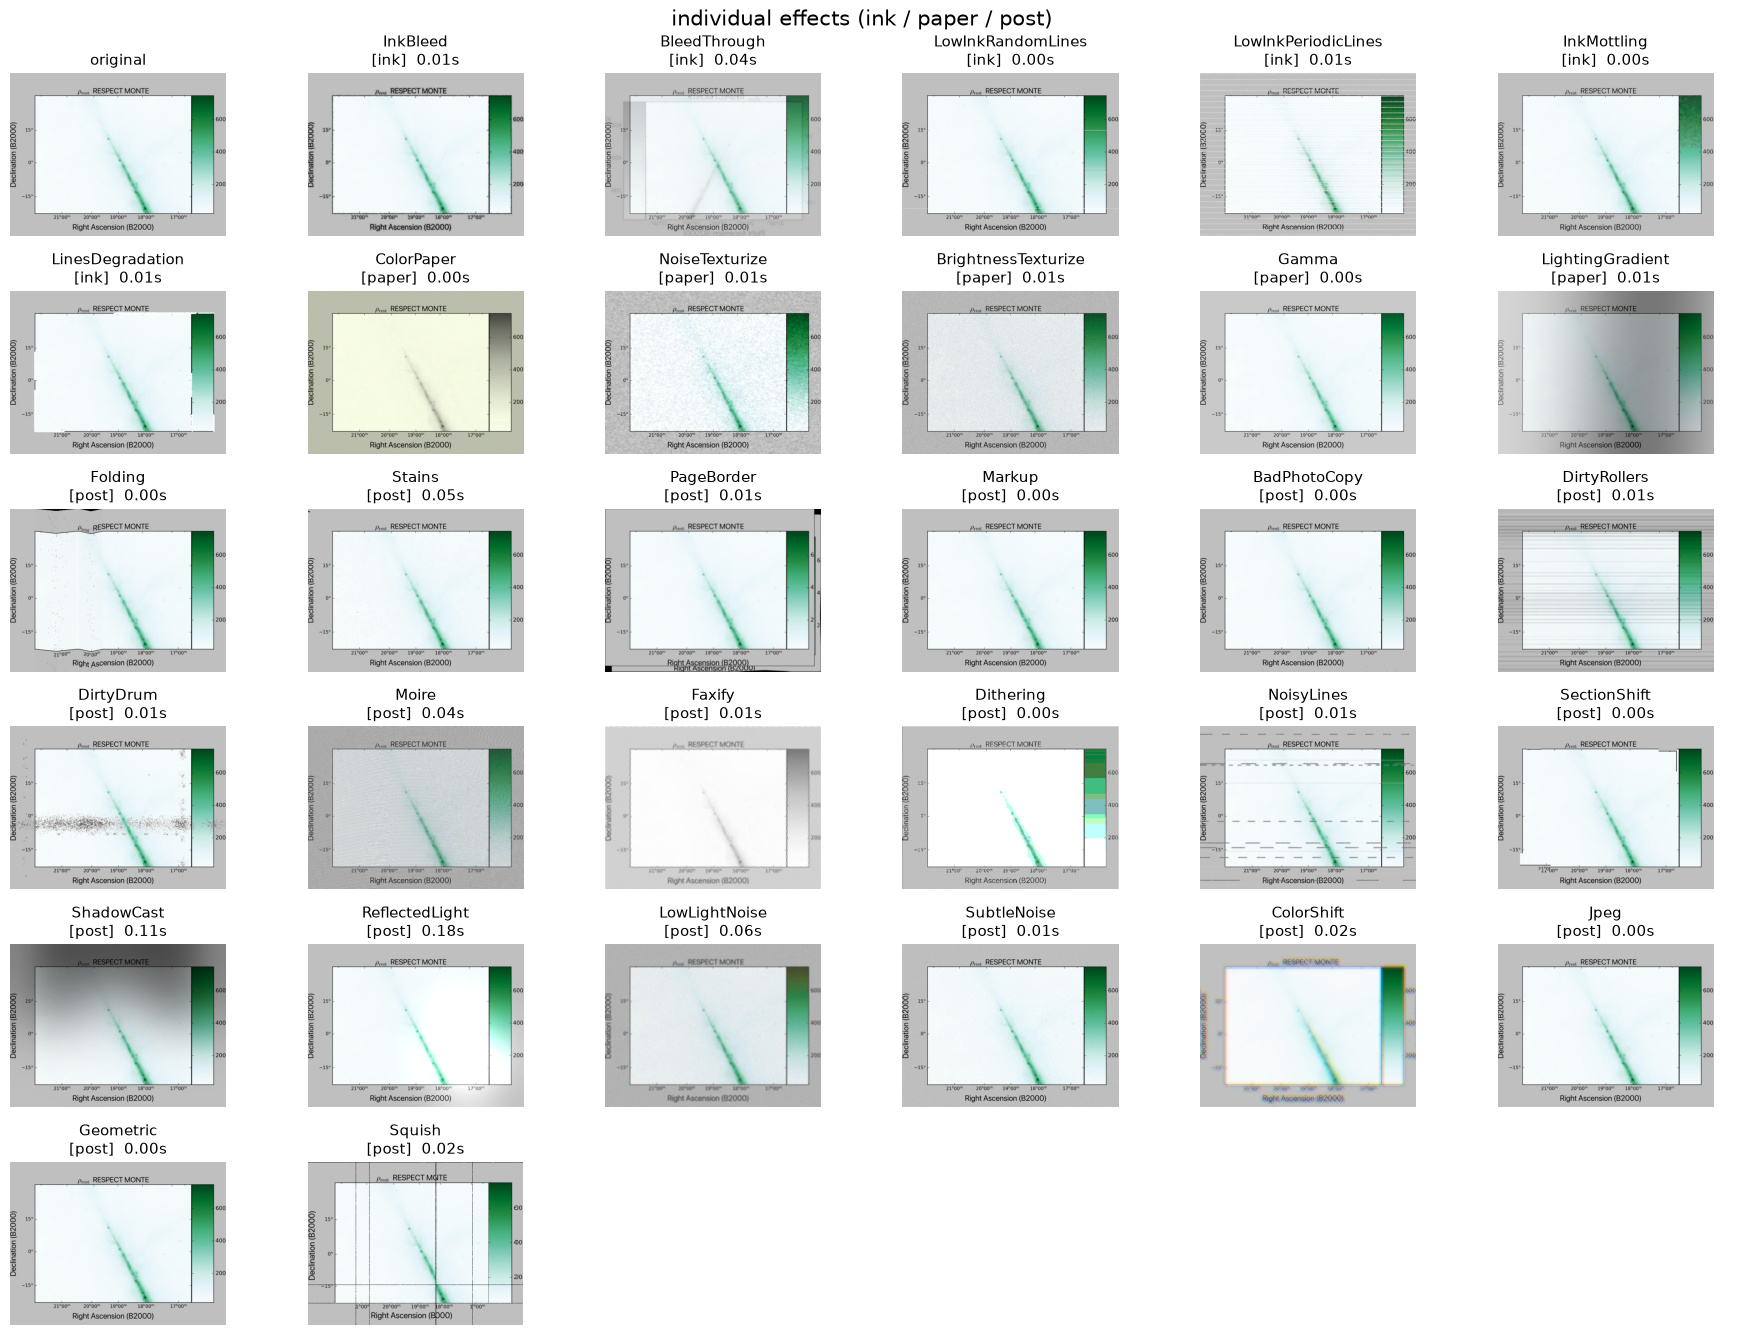

In [9]:
# ==================== EFFECT GALLERY ====================
# Every effect on its own, so you can see what each contributes and build your
# own preset.  Small image -- this is 35 separate augmentations.

gimg = load_image(input_image, max_width=gallery_max_width)

gallery, gtitles, failed = [gimg], ['original'], []
for name, (phase, factory) in EFFECTS.items():
    if not effect_enabled(name):
        continue
    try:
        t0 = time.time()
        gallery.append(factory()(gimg.copy()))
        gtitles.append('%s\n[%s]  %.2fs' % (name, phase, time.time() - t0))
    except Exception as e:
        failed.append((name, type(e).__name__))

fig = show(gallery, gtitles, ncols=6, width=3.0,
           suptitle='individual effects (ink / paper / post)')
fig.savefig(os.path.join(out_dir, '%s_effect_gallery.png' % stem),
            dpi=100, bbox_inches='tight')
print('wrote', os.path.join(out_dir, '%s_effect_gallery.png' % stem))
if failed:
    print('failed:', failed)


wrote ./aged_output/vqa_000001_effect_gallery_annotated.png
effects that moved the boxes: Folding, SectionShift, Squish
skipped: [('Markup', 'TypeError')]


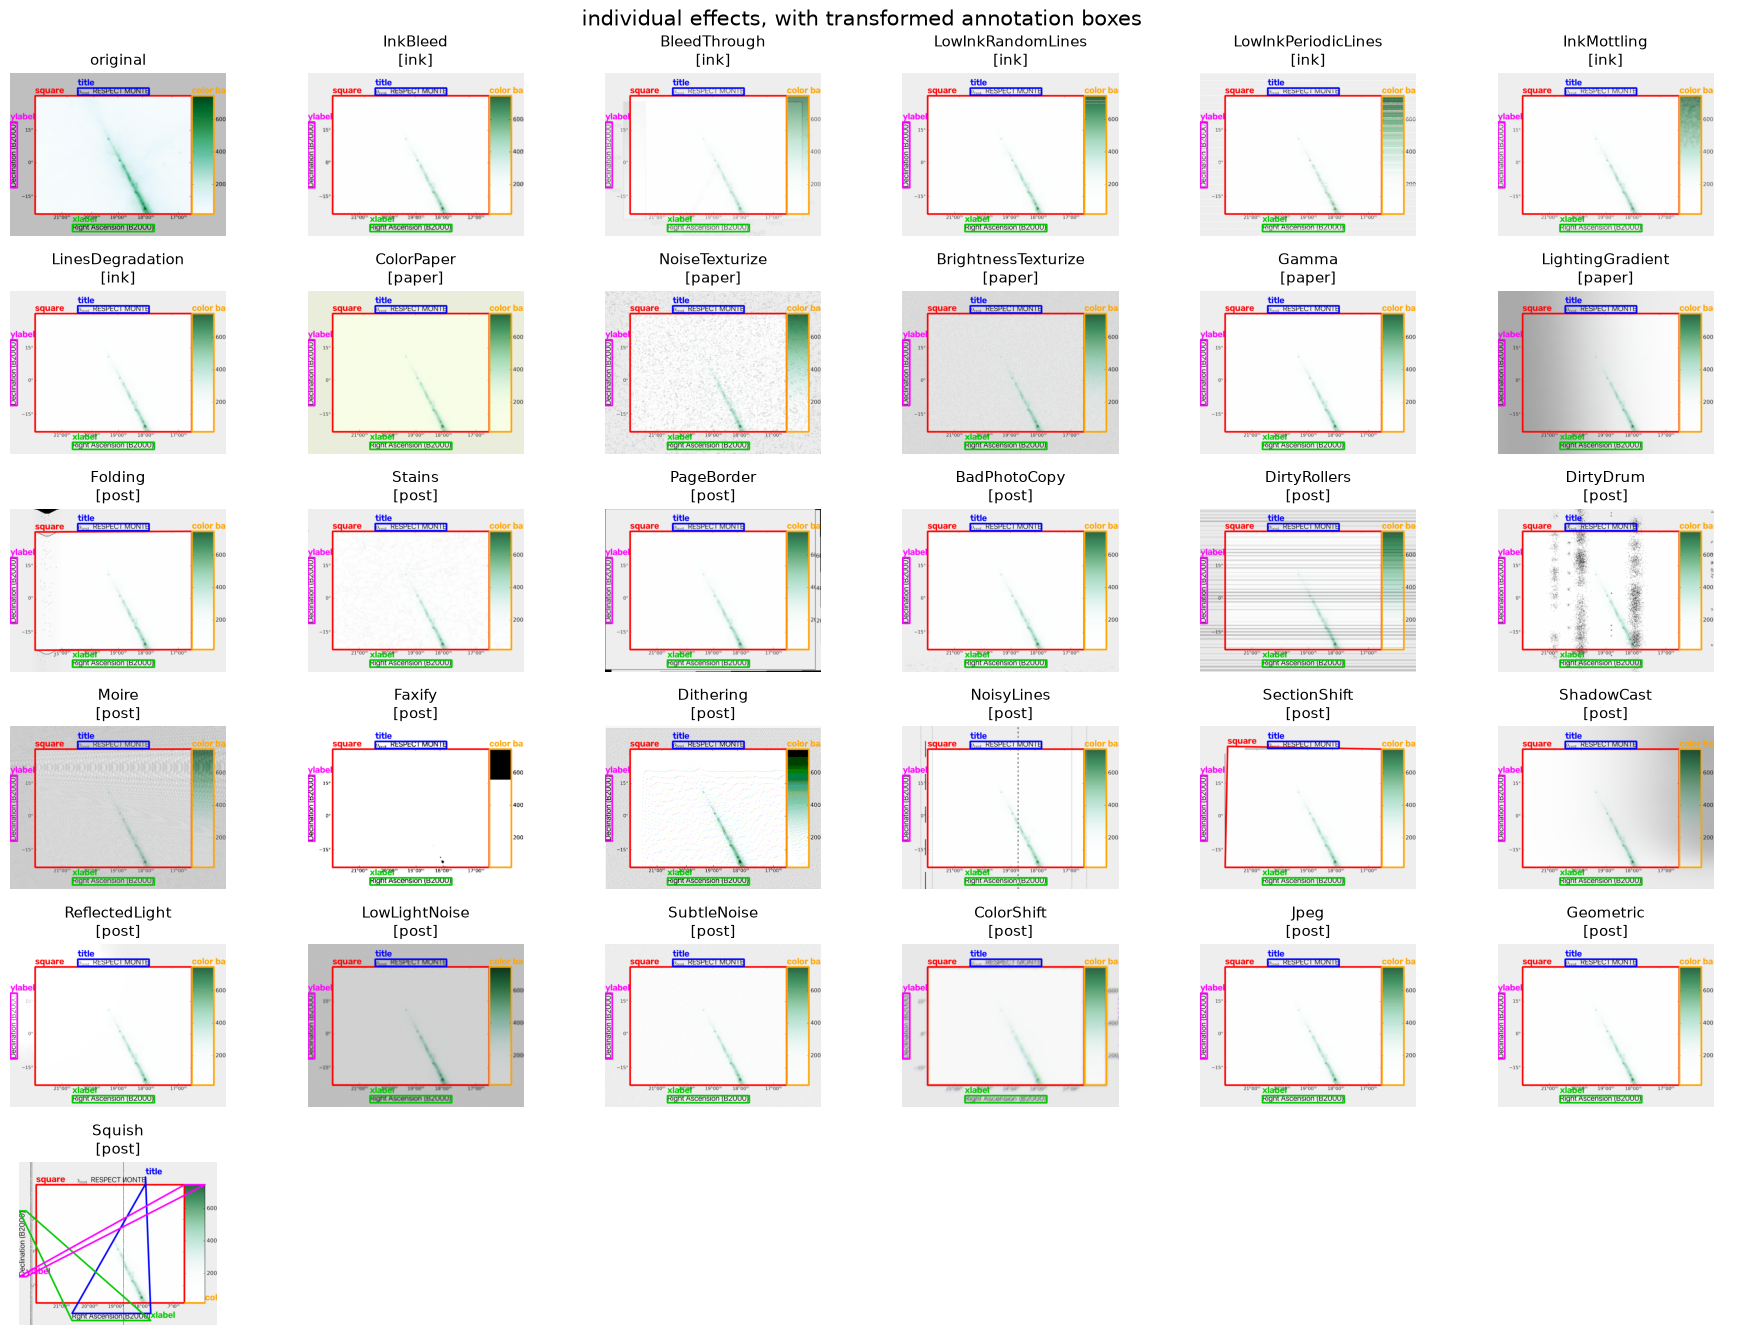

In [10]:
# ---------- effect gallery, annotated ----------
# One effect at a time, with the boxes carried through it.  Only the geometric
# effects move them; for the rest the boxes should sit exactly where they do on
# the clean figure, which is a useful check that nothing is drifting.
if quads:
    gfull = load_image(input_image)
    sg = gimg.shape[1] / gfull.shape[1]
    gquads = [(lab, [[int(round(x*sg)), int(round(y*sg))] for x, y in q])
              for lab, q in collect_quads(datas_plot, gfull.shape[0])]

    gal_a, gtitles_a, moved_any, failed_a = [annotate(gimg, gquads)], ['original'], [], []
    for name, (phase, factory) in EFFECTS.items():
        if not effect_enabled(name):
            continue
        try:
            labels, keypoints = flatten_quads(gquads)
            res = AugraphyPipeline(**{phase + '_phase': [factory()]},
                                   keypoints=keypoints, random_seed=seed)(gimg.copy())
            a, qm = unpack_result(res, labels, keypoints['annotation_corners'])
        except Exception as e:
            # a couple of augraphy augmentations trip over their own RNG draws
            # when run through a seeded pipeline (Markup feeds a float into
            # random.randint); skip rather than lose the whole gallery
            failed_a.append((name, type(e).__name__))
            continue
        if [q for _, q in qm] != [q for _, q in gquads]:
            moved_any.append(name)
        gal_a.append(annotate(a, qm))
        gtitles_a.append('%s\n[%s]' % (name, phase))

    fig = show(gal_a, gtitles_a, ncols=6, width=3.0,
               suptitle='individual effects, with transformed annotation boxes')
    out_a = os.path.join(out_dir, '%s_effect_gallery_annotated.png' % stem)
    fig.savefig(out_a, dpi=100, bbox_inches='tight')
    print('wrote', out_a)
    print('effects that moved the boxes:', ', '.join(moved_any) or 'none')
    if failed_a:
        print('skipped:', failed_a)
